# Gravimetry corrections

The supplied data should include the correction data in separate channels, and these data can be checked with the four QC functions below.

Here we use the Eastern Victoria airborne gravity survey data that was imported into a geowhizz file in the Data_Import notebook.

___

Import the required modules, and set the path to the geowhizz files.

In [1]:
from pathlib import Path

import galileoQC as qc

EastVicHDF_file = Path(r'./EastVicData/EastVic.hdf5')

In [2]:
if not EastVicHDF_file.exists():
    %run ./Prepare_EastVicData.ipynb

___

As the aircraft changes height, the mass of atmosphere above the gravimeter changes and the consequent change in the measured gravity must be corrected for. The **atmospheric correction** should be:

$$\delta g_{atm}=8.74 - 9.9 \times 10^{-4} h + 3.56 \times 10^{-8} h^{2}$$

where $h$ is the ellipsoidal height in $m$ and $\delta g_{atm}$ is in $\mu ms^{-2}$.

`checkAtmosEffect` relies on the knowing the units of the atmospheric correction channel. Usually one sets the units when the geowhizz file is created but it can be done at any time by the command (of course, using your own file name, and channel name, and units):

```python
qc.updateChannelAttributes(EastVicHDF_file, 'ATMCOR', units='mGal')
```

The result of `checkAtmosEffect` is a statistical analysis plot showing, for each flight-line, the mean, standard deviation, and range of the difference between the supplied atmospheric correction data and that resulting from the use of the formula above.

Typically there are differences of less than $0.1\,\mu ms^{-2}$ due to the limited precision of the data. Errors up to even $1.0\,\mu ms^{-2}$ are acceptable.

In this example all results are consistent with the correct formula being used and consequently the data pass.

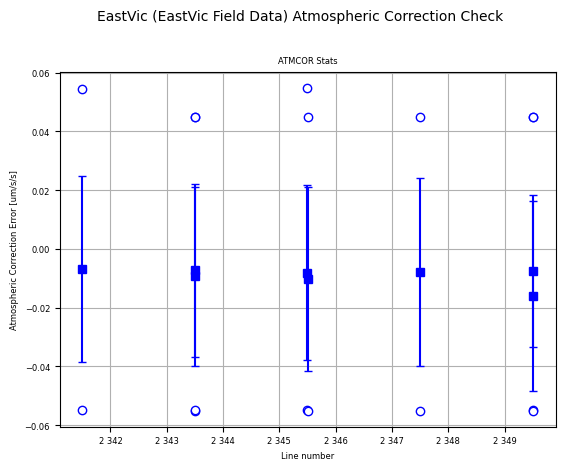

In [3]:
qc.checkAtmosEffect(EastVicHDF_file, 'ATMCOR', GRS80_height='MGA_Z')

The figure above shows a statistical analysis of the atmospheric correction check. The mean (solid squares), range (open circles) and one standard deviation (small horizontal line) summarise the statistics. In this example, all errors are less than $0.06\,\mu m s^{-2}$ which can be attributed to the limited precision of the data in text format.

___

The **free-air, or height, correction** must use the second-order approximation to correct for the vertical gravity effect due to height changes above the GRS80 ellipsoid:

$$\delta g_{h}=-\left(3.087691 - 0.004398 \sin^2{\phi}\right) h + 7.2125 \times 10^{-7} h^{2}$$

where $h$ is the ellipsoidal height in $m$, $\phi$ is the latitude in decimal degrees, and $\delta g_{h}$ is in $\mu ms^{-2}$.

As with `checkAtmosEffect`, `checkFreeAirCorr` relies on the units for the input correction channel being set in the geowhizz file.

The result of `checkFreeAirCorr` is a statistical analysis plot showing, for each flight-line, the mean, standard deviation, and range of the difference between the supplied atmospheric correction data and that resulting from the use of the formula above.

Occasionally, the supplied free-air correction data will have the opposite sign to that in the equation, and `checkFreeAirCorr` provides an optional parameter `changesign` to allow for this possibility. If the results from `checkFreeAirCorr` are much larger than $1.0$, this may be the reason. In that case, simply set `changesign=True` and try again.

Typically there are differences of less than $0.1\,\mu ms^{-2}$ due to the limited precision of the data. Errors up to even $1.0\,\mu ms^{-2}$ are acceptable.

In this example all results are consistent with the correct formula being used and so the data pass.

In [4]:
qc.checkFreeAirCorr(EastVicHDF_file, 'FACOR_GRS80', changesign=True)

NameError: name 'getChannelAttrs' is not defined

The figure above shows a statistical analysis of the atmospheric correction check. The mean (solid squares), range (open circles) and one standard deviation (small horizontal line) summarise the statistics. In this example, all errors are less than $0.07\,\mu m s^{-2}$ which can be attributed to the limited precision of the data in text format.

___

The **Eotvos correction** removes the change in measured gravity due to the change in centrifugal acceleration resulting from the east-west component of the aircraft's velocity. This effect is well-known in marine gravimetry but the higher velocity of an aircraft necessitate the use of a more accurate formula:

$$\delta g_{Eotvos}=2\omega_{E} \nu_{E} \cos\left(\phi\right) + \frac{\nu_{N}^{2}}{R_{M}+h} + \frac{\nu_{E}^{2}}{R_{N}+h}$$

where $\omega_{E}$ is the Earth's rotation rate in radians per second, $\phi$ is the latitude in decimal degrees, $h$ is the ellipsoidal height in $m$, $R_{M}$ and $R_{N}$ are the prime vertical and meridian radii of curvature respectively (in $m$), $\nu_{N}$ and $\nu_{E}$ are the north and east components respectively of the aircraft velocity in $ms^{-2}$ and $\delta g_{Eotvos}$ is in $\mu ms^{-2}$.

As with the other correction check functions, `checkEotvosCorr` relies on the units for the input correction channel being set in the geowhizz file.

The result of `checkEotvosCorr` is a statistical analysis plot showing, for each flight-line, the mean, standard deviation, and range of the difference between the supplied Eotvos correction data and that resulting from the use of the formula above.

Typically there are differences of up to about $1.0\,\mu ms^{-2}$ due to the limited precision of the data. Errors up to a few $\mu ms^{-2}$ are acceptable.

In this example all results are consistent with the correct formula being used and so the data pass.

In [ ]:
qc.checkEotvosCorr(EastVicHDF_file, 'EOTCOR', east_vel='V_EAST', north_vel='V_NORTH', changesign=True)

The figure above shows a statistical analysis of the atmospheric correction check. The mean (solid squares), range (open circles) and one standard deviation (small horizontal line) summarise the statistics. In this example, all errors are less than $0.09\,\mu m s^{-2}$ which can be attributed to the limited precision of the data in text format.

___

The **latitude, or normal, correction** is the theoretical gravity $g_{T}$ on the GRS80 ellipsoid at latitude (south or north) $\phi$:

$$\delta g_{T}=\frac{g_{e} \left(1+k \sin^2\phi\right)}{\sqrt{\left(1-e^2 \sin^2 \phi\right)}}$$

where $g_{e}$ is 978032.67715 mGal, $k$ is 0.001931851353, and $e^{2}$ is 0.0066943800229.

As with the other gravimetry correction checks, `checkLatCorr` relies on the units for the input correction channel being set in the geowhizz file.

The result of `checkLatCorr` is a statistical analysis plot showing, for each flight-line, the mean, standard deviation, and range of the difference between the supplied latitude correction data and that resulting from the use of the formula above.

Occasionally, the supplied latitude correction data will have the opposite sign to that in the equation, and `checkLatCorr` provides an optional parameter `changesign` to allow for this possibility. If the results from `checkLatCorr` are much larger than $1.0$, this may be the reason. In that case, simply set `changesign=True` and try again.

Typically there are differences of less than $0.1\,\mu ms^{-2}$ due to the limited precision of the data. Errors up to even $1.0\,\mu ms^{-2}$ are acceptable.

In this example all results are consistent with the correct formula being used and consequently the data pass.

In [ ]:
qc.checkLatCorr(EastVicHDF_file, 'LATCOR')

The figure above shows a statistical analysis of the atmospheric correction check. The mean (solid squares), range (open circles) and one standard deviation (small horizontal line) summarise the statistics. In this example, all errors are less than $0.06\,\mu m s^{-2}$ which can be attributed to the limited precision of the data in text format.